<h1 style="text-align: center;">[Your Project Title]</h1>
<h3 style="text-align: center;"><b>Angela Adytha Putri & Mika Mahaputra</b></h3>

---

# **Section 0. Setup**

> 🎯 *Tujuan:* Menyiapkan environment kerja (import library, konfigurasi global) supaya proses selanjutnya konsisten dan reproducible.

## **0.1 Import Library**

> 🎯 *Tujuan:* Memuat semua library yang dibutuhkan di satu tempat di awal, supaya dependency notebook mudah dilacak.

In [1]:
# import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tambahkan import lain sesuai kebutuhan (sklearn, dll) di sini

## **0.2 Global Configuration**

> 🎯 *Tujuan:* Menetapkan parameter global seperti random_state di satu tempat, supaya semua proses (split, model, CV) memakai nilai yang sama.

> 📌 **Catatan untuk Peserta:** Selalu set `RANDOM_STATE` di satu tempat dan pakai variabel yang sama di semua proses (train_test_split, model, cross-validation). Ini membuat hasil eksperimenmu **reproducible** — orang lain (atau kamu sendiri, minggu depan) bisa menjalankan ulang notebook dan dapat hasil yang sama persis.

In [2]:
RANDOM_STATE = 9
pd.set_option('display.max_columns', None)

# **Section 1. Business Understanding**

> 🎯 *Tujuan:* Menerjemahkan masalah bisnis menjadi masalah yang bisa diselesaikan dengan machine learning, sebelum menyentuh data sama sekali.

## **1.1 Context**

> 🎯 *Tujuan:* Menjelaskan latar belakang bisnis: siapa stakeholder-nya dan kenapa masalah ini perlu diselesaikan sekarang.

&emsp;&emsp;&emsp;E-commerce ini menghadapi tantangan retensi pelanggan yang berdampak langsung pada pertumbuhan revenue jangka panjang. **Mengakuisisi pelanggan baru membutuhkan biaya (CAC) yang jauh lebih besar dibanding mempertahankan pelanggan lama** — riset industri menunjukkan biaya akuisisi bisa 5-7 kali lipat dari biaya retensi. Artinya, setiap pelanggan yang churn (berhenti bertransaksi) bukan hanya kehilangan satu transaksi, tapi kehilangan seluruh potential lifetime value (LTV) yang sudah diinvestasikan sejak proses akuisisi.

**Stakeholder utama proyek ini:**
- **Marketing Team** — membutuhkan insight untuk merancang program retensi (promo, loyalty program, personalisasi) yang tepat sasaran, bukan disebar merata ke semua pelanggan.
- **Customer Success / CRM Team** — membutuhkan daftar pelanggan berisiko tinggi churn untuk dilakukan intervensi proaktif (follow-up, penawaran khusus) sebelum pelanggan benar-benar pergi.
- **Management / Business Owner** — membutuhkan estimasi dampak finansial dari churn sebagai dasar keputusan alokasi budget retensi.

&emsp;&emsp;&emsp;Saat ini, tim retensi masih bekerja secara **reaktif** — intervensi baru dilakukan setelah pelanggan menunjukkan tanda churn yang sudah jelas (misal berhenti transaksi berbulan-bulan), sehingga peluang untuk mempertahankan pelanggan tersebut sudah sangat kecil. Belum ada mekanisme **early warning system** berbasis data yang bisa mendeteksi sinyal churn lebih awal.

&emsp;&emsp;&emsp;Proyek ini bertujuan mengubah pendekatan tersebut menjadi **proaktif**, dengan memanfaatkan data historis profil dan perilaku transaksi pelanggan untuk memprediksi risiko churn sebelum benar-benar terjadi, sehingga tim bisnis punya cukup waktu untuk melakukan intervensi.

## **1.2 Problem Statements**

> 🎯 *Tujuan:* Merumuskan masalah secara spesifik dan terukur, biasanya dalam bentuk pertanyaan yang bisa dijawab lewat data.

&emsp;&emsp;&emsp;Berdasarkan konteks bisnis di atas, masalah dirumuskan menjadi beberapa pertanyaan yang bisa dijawab lewat data:
1. **Pelanggan mana saja yang memiliki risiko tinggi untuk churn dalam waktu dekat?** — perlu diketahui di level individu pelanggan, bukan hanya angka churn rate agregat, supaya bisa langsung ditindaklanjuti oleh tim retensi.
2. **Faktor-faktor apa yang paling memengaruhi keputusan pelanggan untuk berhenti bertransaksi?** — misalnya lama berlangganan (tenure), tingkat kepuasan, frekuensi order, metode pembayaran, jumlah komplain, atau jarak pengiriman.
3. **Bagaimana tim bisnis bisa mengalokasikan budget retensi secara lebih efisien**, mengingat tidak semua pelanggan memiliki risiko dan value yang sama sehingga treatment yang diberikan seharusnya tidak disamaratakan?

&emsp;&emsp;&emsp;Ketiga pertanyaan ini menjadi acuan utama dalam proses eksplorasi data (Section 4) dan akan dijawab langsung di Section 8 (Model Implementation) serta Section 9 (Conclusion and Recommendation).

## **1.3 Goals**

> 🎯 *Tujuan:* Menetapkan target yang ingin dicapai proyek ini, sebagai turunan langsung dari problem statement di atas.

&emsp;&emsp;&emsp;Turunan langsung dari Problem Statement di atas, tujuan proyek ini adalah:
1. **Membangun model machine learning klasifikasi yang mampu memprediksi probabilitas churn tiap pelanggan**, sehingga tim retensi dapat memprioritaskan pelanggan berisiko tinggi lebih awal.
2. **Mengidentifikasi fitur-fitur yang paling berkontribusi terhadap churn**, sebagai dasar rekomendasi strategi retensi yang lebih tepat sasaran (data-driven, bukan asumsi).
3. **Mengestimasi dampak bisnis (potential revenue yang bisa diselamatkan)** dari penerapan model ini dibandingkan pendekatan business-as-usual tanpa model.

&emsp;&emsp;&emsp;Ketiga goals ini akan dipakai sebagai acuan untuk menilai keberhasilan proyek di Section 9.1.

## **1.4 Analytical Approach**

> 🎯 *Tujuan:* Menentukan pendekatan analitis/teknis (misal klasifikasi atau regresi) yang akan dipakai untuk mencapai goals.

&emsp;&emsp;&emsp;Target yang ingin diprediksi bersifat kategorikal biner (**Churn**: 1 = churn, 0 = tidak churn), sehingga pendekatan analitis yang digunakan adalah **klasifikasi (binary classification)**.

Alur pendekatan yang akan dijalankan:
1. **Data Understanding & EDA** — memahami karakteristik pelanggan yang churn vs tidak churn, serta mengecek keseimbangan kelas target.
2. **Data Preparation** — membersihkan data, menangani missing value, encoding, scaling, dan menangani class imbalance jika target tidak seimbang.
3. **Model Benchmarking** — membandingkan beberapa algoritma klasifikasi (misal Logistic Regression sebagai baseline interpretable, serta Decision Tree/Random Forest/boosting sebagai kandidat performa lebih tinggi) menggunakan cross-validation.
4. **Model Tuning** — melakukan hyperparameter tuning pada kandidat model terbaik.
5. **Model Interpretation** — menggunakan feature importance / SHAP untuk menjawab pertanyaan "faktor apa yang paling berpengaruh" di Section 1.2 poin 2.
6. **Business Simulation** — menerjemahkan output probabilitas model menjadi keputusan bisnis konkret (siapa yang perlu ditargetkan program retensi) di Section 8.

## **1.5 Metric Evaluation**

> 🎯 *Tujuan:* Menjembatani metrik bisnis (misal estimasi kerugian) dengan metrik ML (misal precision/recall) yang nanti dipakai mengevaluasi model.

### **Business Metric**

&emsp;&emsp;&emsp;Ada dua jenis kesalahan prediksi yang punya konsekuensi biaya berbeda:
- **False Negative (FN)** — pelanggan yang sebenarnya akan churn tapi diprediksi tidak churn → tim retensi tidak melakukan intervensi apa-apa → **berpotensi kehilangan seluruh future revenue/LTV dari pelanggan tersebut**.
- **False Positive (FP)** — pelanggan yang sebenarnya tidak akan churn tapi diprediksi churn → tim retensi memberi promo/diskon yang sebetulnya tidak diperlukan → **biaya program retensi yang terbuang**, tapi jauh lebih kecil dibanding kehilangan pelanggan.

&emsp;&emsp;&emsp;Karena **cost of FN >> cost of FP** dalam konteks bisnis ini, evaluasi model diarahkan untuk meminimalkan False Negative Rate tanpa mengabaikan Precision sepenuhnya.

### **Machine Learning Metric**
- **Confusion Matrix** dan **ROC-AUC** digunakan sebagai pelengkap untuk melihat trade-off secara menyeluruh dan membantu menentukan threshold keputusan yang optimal (Section 6.5-6.6).
- **Recall** sebagai metrik utama — mengukur seberapa banyak pelanggan yang benar-benar churn berhasil ditangkap oleh model.
- **Precision** tetap dipantau sebagai metrik pendamping — supaya budget retensi tidak habis untuk pelanggan yang salah target.
- **F2-Score** dipakai sebagai metrik gabungan yang memberi bobot lebih besar ke Recall dibanding Precision, konsisten dengan prioritas bisnis di atas.

## **1.6 Success Criteria**

> 🎯 *Tujuan:* Menetapkan ambang batas angka (misal minimal recall 80%) yang menentukan apakah model dianggap layak dipakai.

&emsp;&emsp;&emsp;Model dinyatakan layak digunakan apabila memenuhi kriteria berikut pada data testing:
- **Recall minimal 75-80%** — memastikan mayoritas pelanggan berisiko churn berhasil teridentifikasi oleh model.
- **Precision minimal 50%** — menjaga supaya program retensi tidak terlalu banyak salah sasaran ke pelanggan yang sebenarnya tidak akan churn.
- **F2-Score model mengungguli baseline** (misal majority class prediction/model tanpa tuning) secara signifikan.
- **Estimasi revenue yang berhasil diselamatkan** (dihitung di Section 8.3 menggunakan data unseen) harus lebih besar dibanding biaya operasional program retensi yang dijalankan berdasarkan hasil prediksi model.

> 📌 Catatan: Angka threshold di atas adalah asumsi awal berbasis pertimbangan bisnis umum, dan dapat disesuaikan kembali setelah melihat distribusi data aktual (proporsi kelas churn) serta diskusi lebih lanjut dengan stakeholder bisnis.

# **Section 2. Data Understanding**

> 🎯 *Tujuan:* Mengenali data secara umum — bentuk, tipe, dan makna tiap fitur — sebelum melakukan pembersihan atau analisis mendalam.

In [3]:
df_raw = pd.read_csv('../data/raw/customer_churn.csv')
df_raw

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


## **2.1 General Information**

> 🎯 *Tujuan:* Melihat ukuran, tipe data, dan struktur umum dataset (jumlah baris, kolom, tipe data tiap kolom).

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 411.2 KB


In [5]:
df_raw.shape

(3941, 11)

In [6]:
df_raw.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


## **2.2 Feature Information**

> 🎯 *Tujuan:* Mendokumentasikan makna tiap fitur dan relevansinya terhadap masalah bisnis di Section 1.

| Fitur | Deskripsi | Dampak Terhadap Bisnis |
| ----- | --------- | ---------------------- |
| Tenure | Lama masa kerja seorang pelanggan di perusahaan | Tenure pendek = *red flag churn* tinggi (pelanggan belum sempat loyal). Ini salah satu prediktor *churn* paling kuat di literatur — hubungan biasanya monoton negatif terhadap *churn*. |
| WarehouseToHome | Jarak antara gudang dengan rumah pelanggan | Jarak jauh -> waktu kirim lebih lama, ongkir lebih mahal -> pengalaman belanja buruk -> *churn* naik. Tapi ini proxy lokasi, bukan penyebab langsung — perlu dicek apakah efeknya linear atau ada threshold. |
| NumberOfDeviceRegistered | Total perangkat yang terdaftar atas nama pelanggan | Ambigu, jangan diasumsikan satu arah. Bisa berarti engagement tinggi (banyak titik akses) ATAU red flag sharing akun/fraud. Arah efeknya perlu dicek lewat EDA (correlation/crosstab dengan *churn*), bukan ditebak. |
| PreferedOrderCat | Kategori barang yang paling sering dibeli oleh pelanggan selama sebulan terakhir | Berguna untuk segmentasi & personalisasi kampanye retensi. Kategori tertentu (misal barang sekali beli vs consumable) kemungkinan punya *churn* rate beda — perlu breakdown *churn* rate per kategori sebelum diklaim sebagai driver. |
| SatisfactionScore | Nilai kepuasan pelanggan terhadap layanan | Prediktor langsung dan intuitif: skor rendah -> risiko *churn* tinggi. Tapi self-reported score sering bias (skor rendah tidak selalu diikuti *churn*, dan sebaliknya) — validasi dengan data historis *churn*, jangan asumsikan linear. |
| MaritalStatus | Status pernikahan pelanggan | Dampak bisnis paling lemah di tabel ini. Paling banter jadi proxy demografis untuk targeting promosi (mis. keluarga vs single), bukan driver *churn* yang kuat kecuali EDA membuktikan sebaliknya. |
| NumberOfAddress | Total alamat yang didaftarkan oleh pelanggan | Dua arah yang mungkin bertentangan: (1) banyak alamat = pelanggan aktif dengan kebutuhan beragam (loyal), atau (2) indikasi ketidakstabilan/berbagi akun -> *churn* risk naik. Jangan tentukan arah sebelum cek data. |
| Complain | Total keluhan yang diajukan oleh pelanggan selama sebulan terakhir | Prediktor kuat dan actionable: komplain naik -> *churn* naik. Ini variabel yang paling langsung bisa dijadikan trigger retention campaign (mis. follow-up otomatis setelah komplain). |
| DaySinceLastOrder | Total hari sejak pelanggan terakhir kali melakukan pesanan | Sinyal recency — makin lama, makin besar risiko disengagement/*churn*. Ini biasanya salah satu fitur paling prediktif di model *churn* (mirip RFM). |
| CashbackAmount | Rata-rata *cashback* pada bulan lalu | Cashback tinggi bisa menahan *churn* jangka pendek, tapi ini insentif finansial, bukan loyalitas asli — kalau cashback dipotong, retensi bisa jatuh cepat (dependency risk). Jangan diklaim sebagai "loyalitas" di narasi bisnis. |
| *Churn* | 0 - Pelanggan TIDAK melakukan **churn**, 1 - Pelanggan melakukan **churn** | Bukan fitur — ini label yang diprediksi. Kalau ditaruh di tabel fitur, itu keliru secara metodologis (bisa jadi data leakage kalau ikut dipakai sebagai input model). |

> 📌 Baris contoh di atas menunjukkan pola pengisian: kolom terakhir bukan sekadar deskripsi ulang, tapi jawaban dari *"kenapa fitur ini penting buat masalah bisnis di Section 1?"*. Hapus baris contoh dan isi dengan fitur asli datasetmu.

## **2.3 Statistics Summary**

> 🎯 *Tujuan:* Melihat ringkasan statistik deskriptif (mean, median, min-max, dsb) untuk menangkap gambaran awal distribusi data.

In [7]:
df_raw.describe(include='all')

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941,3941.000000,3941,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
unique,NaN,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1458,NaN,2055,NaN,NaN,NaN,NaN,NaN
mean,10.081398,15.650583,3.679269,NaN,3.088302,NaN,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,NaN,1.381832,NaN,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,7.000000,195.250000,0.000000


# **Section 3. Data Cleaning**

> 🎯 *Tujuan:* Memastikan data bebas dari masalah kualitas (missing value, duplikat, inkonsistensi) sebelum dipakai lebih lanjut.

## **3.0 Make Copy of Datasets**

In [8]:
df = df_raw.copy()

## **3.1 Missing Values**

> 🎯 *Tujuan:* Mengidentifikasi kolom yang punya data hilang dan menentukan strategi menanganinya (drop, imputasi, atau dibiarkan dengan alasan tertentu).

In [9]:
print(' === MISSING VALUES ===')
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(f'Total missing values: {missing_summary['Missing Count'].sum()}')
display(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing (%)', ascending=False))

 === MISSING VALUES ===
Total missing values: 576


,Missing Count,Missing (%)
DaySinceLastOrder,213,5.40
Tenure,194,4.92
WarehouseToHome,169,4.29


> Ditemukan *missing values* pada kolom `DaySinceLastOrder`, `Tenure`, dan `WarehouseToHome`. Oleh karena itu, perlu dilakukan analisis pola *missing values* pada kolom-kolom tersebut.

In [10]:
# Menampilkan data yang memiliki nilai kosong
df[df.isnull().any(axis=1)]

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
10,6.0,26.0,6,Fashion,3,Married,5,0,NaN,221.10,0
13,1.0,7.0,5,Fashion,3,Divorced,7,0,NaN,231.09,1
16,NaN,21.0,5,Mobile,1,Married,1,1,3.0,121.68,0
27,0.0,NaN,1,Mobile,3,Single,4,1,3.0,124.32,1
...,...,...,...,...,...,...,...,...,...,...,...
3900,0.0,NaN,4,Mobile,1,Single,2,1,0.0,124.39,1
3904,2.0,28.0,2,Fashion,4,Married,8,0,NaN,219.96,0
3907,2.0,NaN,3,Mobile,5,Divorced,8,1,2.0,124.04,1
3925,NaN,8.0,4,Mobile,3,Single,2,0,2.0,120.44,1


In [11]:
# Buat flag: 1 = missing, 0 = ada
df['missing'] = df[['DaySinceLastOrder', 'Tenure', 'WarehouseToHome']].isna().any(axis=1).astype(int)

In [12]:
for col in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    print(f'=== {col} — per Churn ===')
    print(f'{df.groupby('Churn')[f'{col}_missing'].mean().round(3)}\n')

=== Tenure — per Churn ===
Churn
0    0.040
1    0.095
Name: Tenure_missing, dtype: float64

=== WarehouseToHome — per Churn ===
Churn
0    0.033
1    0.089
Name: WarehouseToHome_missing, dtype: float64

=== DaySinceLastOrder — per Churn ===
Churn
0    0.053
1    0.059
Name: DaySinceLastOrder_missing, dtype: float64



In [13]:
for col in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    print(f'=== {col} — per PreferedOrderCat ===')
    print(f'{df.groupby('PreferedOrderCat')[f'{col}_missing'].mean().round(3)}\n')

=== Tenure — per PreferedOrderCat ===
PreferedOrderCat
Fashion               0.000
Grocery               0.000
Laptop & Accessory    0.005
Mobile                0.270
Mobile Phone          0.039
Others                0.000
Name: Tenure_missing, dtype: float64

=== WarehouseToHome — per PreferedOrderCat ===
PreferedOrderCat
Fashion               0.000
Grocery               0.000
Laptop & Accessory    0.005
Mobile                0.290
Mobile Phone          0.000
Others                0.000
Name: WarehouseToHome_missing, dtype: float64

=== DaySinceLastOrder — per PreferedOrderCat ===
PreferedOrderCat
Fashion               0.284
Grocery               0.044
Laptop & Accessory    0.024
Mobile                0.000
Mobile Phone          0.000
Others                0.000
Name: DaySinceLastOrder_missing, dtype: float64



In [14]:
for col in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    print(f'=== {col} — per MaritalStatus ===')
    print(f'{df.groupby('MaritalStatus')[f'{col}_missing'].mean().round(3)}\n')

=== Tenure — per MaritalStatus ===
MaritalStatus
Divorced    0.054
Married     0.045
Single      0.053
Name: Tenure_missing, dtype: float64

=== WarehouseToHome — per MaritalStatus ===
MaritalStatus
Divorced    0.043
Married     0.036
Single      0.053
Name: WarehouseToHome_missing, dtype: float64

=== DaySinceLastOrder — per MaritalStatus ===
MaritalStatus
Divorced    0.052
Married     0.059
Single      0.047
Name: DaySinceLastOrder_missing, dtype: float64



In [15]:
flag_cols = [c for c in df.columns if c.endswith('_missing') or c == 'missing']
df.drop(columns=flag_cols, inplace=True)

# ── Imputasi median per grup Churn (strategi MAR) ────────────────────────
for col in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']:
    df[col] = df.groupby('Churn')[col].transform(lambda x: x.fillna(x.median()))

# ── Verifikasi ───────────────────────────────────────────────────────────
remaining = df.isnull().sum().sum()
print(f'   Missing values setelah imputasi: {remaining}')
print(f'   Shape: {df.shape}')

   Missing values setelah imputasi: 0
   Shape: (3941, 11)


### **Analisis Proporsi Missing Value Berdasarkan Variabel Kategorikal**

Untuk memahami pola *missingness* pada variabel `Tenure`, `WarehouseToHome`, dan `DaySinceLastOrder`, 
proporsi nilai hilang dihitung berdasarkan tiga variabel kategorikal: `Churn`, `PreferedOrderCat`, 
dan `MaritalStatus`. Pemilihan ketiga variabel ini didasarkan pada pertimbangan berikut:

**1. Churn (Target Variable)**

Pengelompokan berdasarkan `Churn` bertujuan untuk mendeteksi kemungkinan pola *Missing Not At Random* 
(MNAR), yaitu kondisi di mana ketiadaan data itu sendiri berkorelasi dengan target prediksi. Apabila 
proporsi missing value pada kelompok churn (1) berbeda signifikan dari kelompok non-churn (0), hal ini 
mengindikasikan bahwa hilangnya data bukan kejadian acak, melainkan berkaitan dengan perilaku pelanggan 
yang berujung churn (misalnya, pelanggan yang akan churn cenderung berhenti bertransaksi sebelum data 
sempat tercatat lengkap). Temuan ini penting karena strategi imputasi yang tidak mempertimbangkan pola 
ini berisiko menghilangkan sinyal prediktif yang relevan terhadap target.

**2. PreferedOrderCat**

Pengelompokan berdasarkan kategori pesanan yang disukai bertujuan untuk mengevaluasi apakah missing 
value berasal dari proses pencatatan data (*data-generating process*) yang berbeda antar kategori 
produk atau kanal transaksi. Jika proporsi missing value bervariasi signifikan antar kategori, hal ini 
mengarah pada pola *Missing At Random* (MAR), di mana ketiadaan data dapat dijelaskan oleh variabel lain 
yang teramati (dalam hal ini kategori pesanan), sehingga imputasi sebaiknya dilakukan secara terpisah 
per kelompok, bukan menggunakan nilai global.

Secara keseluruhan, analisis terhadap `Churn` dan `PreferedOrderCat` menjadi prioritas utama karena 
memiliki implikasi langsung terhadap penentuan strategi imputasi yang tepat, sementara analisis terhadap 
`MaritalStatus` bersifat pelengkap untuk memastikan tidak ada pola tersembunyi yang terlewat.

## **3.2 Duplicated Values**

> 🎯 *Tujuan:* Mengecek baris data yang terduplikasi penuh maupun sebagian (misal duplikat berdasarkan ID).

In [16]:
print('=== DUPLICATE VALUES ===')
duplicate_summary_stores = pd.DataFrame({
    'Duplicate Count': [df.duplicated().sum()],
    'Duplicate (%)': [round(df.duplicated().sum() / len(df) * 100, 2)]
}, index=['Total'])
display(duplicate_summary_stores[duplicate_summary_stores['Duplicate Count'] > 0].sort_values('Duplicate (%)', ascending=False))

=== DUPLICATE VALUES ===


,Duplicate Count,Duplicate (%)
Total,671,17.03


In [17]:
print(' === DUPLICATED COLUMNS ===')
duplicated_summary = pd.DataFrame({
    'Duplicate Count': df.apply(lambda col: col.duplicated().sum()),
    'Duplicate (%)': df.apply(lambda col: (col.duplicated().sum() / len(df) * 100).round(2))
})
display(duplicated_summary[duplicated_summary['Duplicate Count'] > 0].sort_values('Duplicate (%)', ascending=False))

 === DUPLICATED COLUMNS ===


,Duplicate Count,Duplicate (%)
Churn,3939,99.95
Complain,3939,99.95
MaritalStatus,3938,99.92
SatisfactionScore,3936,99.87
PreferedOrderCat,3935,99.85
NumberOfDeviceRegistered,3935,99.85
NumberOfAddress,3927,99.64
DaySinceLastOrder,3919,99.44
WarehouseToHome,3908,99.16
Tenure,3905,99.09


In [18]:
# ── Drop duplikat & reset index ─────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'   Duplikat dihapus: {before - after} baris')
print(f'   Shape: {before} → {after} baris')

   Duplikat dihapus: 671 baris
   Shape: 3941 → 3270 baris


## **3.3 Data Consistency Check**
- Spelling errors / typo pada kategori
- Inkonsistensi kapitalisasi & format penulisan
- Whitespace tersembunyi

> 🎯 *Tujuan:* Menyeragamkan penulisan nilai kategorikal supaya kategori yang sebenarnya sama tidak terbaca sebagai kategori berbeda oleh model.

In [19]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    print(f'{df[col].value_counts().to_string()}\n')

PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone           725
Fashion                484
Mobile                 458
Grocery                241
Others                 149

MaritalStatus
Married     1686
Single      1008
Divorced     576



C:\Users\MIka\AppData\Local\Temp\ipykernel_55780\2766421906.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [20]:
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

print('PreferedOrderCat setelah normalisasi:')
print(df['PreferedOrderCat'].value_counts())

PreferedOrderCat setelah normalisasi:
PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone          1183
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64


> 📌 Jangan hanya cek typo. Kesalahan yang jauh lebih sering muncul di data nyata adalah inkonsistensi format, misalnya kategori yang sama tapi ditulis berbeda seperti `"Yes"`, `"yes"`, dan `"YES "` (dengan spasi tersembunyi) — ini dianggap 3 kategori berbeda oleh model kalau tidak dibersihkan.

## **3.4 Identify Anomaly Values**
- Check Distribution (Numerical Variable)
- Check Cardinality (Categorical Variable)

> 🎯 *Tujuan:* Mendeteksi nilai yang secara statistik tidak wajar (outlier pada numerik, kategori dengan cardinality aneh pada kategorikal).

### 3.4.1 Identifikasi Outlier

In [21]:
# Outlier kolom `Tenure`
q1 = df['Tenure'].quantile(0.25)
q3 = df['Tenure'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['Tenure'] < lower) | 
                (df['Tenure'] > upper)
            ]['Tenure'].count())

anomaly_values = (df[
                    (df['Tenure'] < lower) | 
                    (df['Tenure'] > upper)
                ]['Tenure'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -17.5
Batas atas     : 34.5
Jumlah anomali : 4
Nilai anomali  : [61. 51. 60. 50.]


In [22]:
# Outlier kolom `WarehouseToHome`
q1 = df['WarehouseToHome'].quantile(0.25)
q3 = df['WarehouseToHome'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['WarehouseToHome'] < lower) | 
                (df['WarehouseToHome'] > upper)
            ]['WarehouseToHome'].count())

anomaly_values = (df[
                    (df['WarehouseToHome'] < lower) | 
                    (df['WarehouseToHome'] > upper)
                ]['WarehouseToHome'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -7.5
Batas atas     : 36.5
Jumlah anomali : 1
Nilai anomali  : [127.]


In [23]:
# Outlier kolom `NumberOfAddress`
q1 = df['NumberOfAddress'].quantile(0.25)
q3 = df['NumberOfAddress'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['NumberOfAddress'] < lower) | 
                (df['NumberOfAddress'] > upper)
            ]['NumberOfAddress'].count())

anomaly_values = (df[
                    (df['NumberOfAddress'] < lower) | 
                    (df['NumberOfAddress'] > upper)
                ]['NumberOfAddress'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -4.0
Batas atas     : 12.0
Jumlah anomali : 3
Nilai anomali  : [19 22 21]


In [24]:
# Outlier kolom `Complain`
q1 = df['Complain'].quantile(0.25)
q3 = df['Complain'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['Complain'] < lower) | 
                (df['Complain'] > upper)
            ]['Complain'].count())

anomaly_values = (df[
                    (df['Complain'] < lower) | 
                    (df['Complain'] > upper)
                ]['Complain'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -1.5
Batas atas     : 2.5
Jumlah anomali : 0
Nilai anomali  : []


In [25]:
# Outlier kolom `DaySinceLastOrder`
q1 = df['DaySinceLastOrder'].quantile(0.25)
q3 = df['DaySinceLastOrder'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['DaySinceLastOrder'] < lower) | 
                (df['DaySinceLastOrder'] > upper)
            ]['DaySinceLastOrder'].count())

anomaly_values = (df[
                    (df['DaySinceLastOrder'] < lower) | 
                    (df['DaySinceLastOrder'] > upper)
                ]['DaySinceLastOrder'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -5.5
Batas atas     : 14.5
Jumlah anomali : 40
Nilai anomali  : [17. 30. 18. 16. 15. 46. 31.]


In [26]:
# Outlier kolom `CashbackAmount`
q1 = df['CashbackAmount'].quantile(0.25)
q3 = df['CashbackAmount'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['CashbackAmount'] < lower) | 
                (df['CashbackAmount'] > upper)
            ]['CashbackAmount'].count())

anomaly_values = (df[
                    (df['CashbackAmount'] < lower) | 
                    (df['CashbackAmount'] > upper)
                ]['CashbackAmount'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : 69.02499999999998
Batas atas     : 274.005
Jumlah anomali : 253
Nilai anomali  : [322.17 296.59 303.75 290.81 290.95  56.   324.43 284.92 284.72 292.46
 296.58 293.85 276.03 288.28 282.87 315.81 312.22 295.66 324.73 323.33
 276.39 301.03 292.52 313.24 321.27 279.27 274.65 308.   278.61 299.65
 308.03 305.61 306.72 317.32 301.65 290.33 295.46  12.   280.61 298.47
 320.17 307.   295.45 317.37 320.66 292.92 282.13  25.   302.79 281.72
 319.06 300.67 321.36 316.97 294.36 283.03 274.26 286.06 282.65 307.65
 290.49 316.44 294.59 298.28 315.49 275.67 296.65 299.99 299.26 276.65
 283.   305.41 318.31 315.45 280.41 278.75 289.22   0.   296.74 315.38
 279.24 324.99 321.58 288.24 287.89 293.31 293.35 295.68 291.06 292.99
 291.89 286.24 293.56 293.8  315.68 298.45 288.8  309.3  320.45 295.02
 295.17 321.13 292.02 285.15 291.59 295.99 318.28 324.26 303.61 284.3
 289.47 296.27 290.45 289.37 298.33 317.02 321.65 291.27 316.61 294.06
 287.11 311.06 317.72 274.44 296.26 301.39 292.04 2

### 3.4.2 Identifikasi Kategori dengan *Cardinality* yang Aneh

In [27]:
cat_cols = ['PreferedOrderCat', 'MaritalStatus']

for col in cat_cols:
    print(f'=== {col} ===')
    
    # 1. Rare category
    freq = df[col].value_counts(normalize=True)
    print('Distribusi:')
    print(freq)
    rare = freq[freq < 0.01]
    if len(rare) > 0:
        print(f'⚠ Rare category (<1%): {rare.index.tolist()}')
    
    # 2. Cardinality
    ratio = df[col].nunique() / len(df)
    print(f'nunique={df[col].nunique()}  ratio={ratio:.4f}')
    
    # 3. Variasi penulisan (case/whitespace)
    normalized = df[col].astype(str).str.strip().str.lower()
    mapping = pd.DataFrame({'original': df[col], 'normalized': normalized})
    dupes = mapping.groupby('normalized')['original'].unique()
    dupes = dupes[dupes.apply(len) > 1]
    if len(dupes) > 0:
        print(f'⚠ Variasi penulisan terdeteksi:\n{dupes}')
    
    print()

=== PreferedOrderCat ===
Distribusi:
PreferedOrderCat
Laptop & Accessory    0.370948
Mobile Phone          0.361774
Fashion               0.148012
Grocery               0.073700
Others                0.045566
Name: proportion, dtype: float64
nunique=5  ratio=0.0015

=== MaritalStatus ===
Distribusi:
MaritalStatus
Married     0.515596
Single      0.308257
Divorced    0.176147
Name: proportion, dtype: float64
nunique=3  ratio=0.0009



# **Section 4. Exploratory Data Analysis (EDA)**

> 🎯 *Tujuan:* Menggali pola dan hubungan dalam data training untuk membangun intuisi sebelum masuk ke tahap modeling.

## **4.1 Univariate Analysis**
- Distribusi target
- Distribusi fitur numerik
- Distribusi fitur kategorikal

> 🎯 *Tujuan:* Memahami karakteristik tiap variabel secara individual, termasuk seberapa seimbang distribusi target.

### **4.1.1 Distribusi Target (`Churn`)**


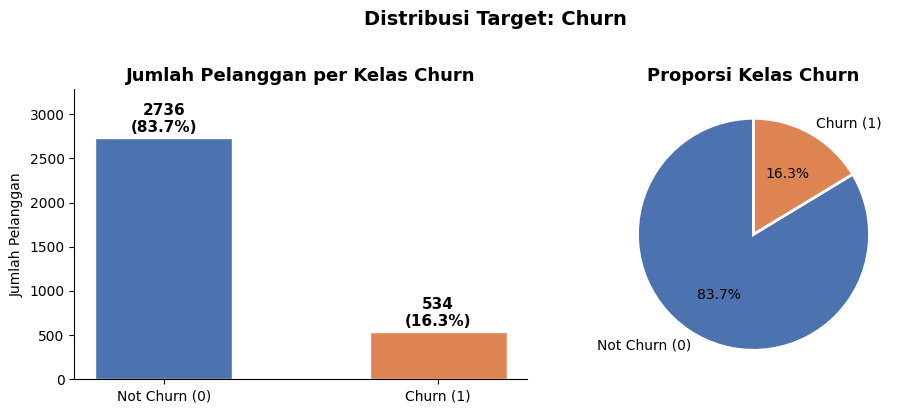

Rasio kelas → Not Churn: 83.7% | Churn: 16.3%
Imbalance ratio (mayoritas:minoritas) ≈ 5.1:1


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
labels       = ['Not Churn (0)', 'Churn (1)']
colors       = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, v + 30, f'{v}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Pelanggan per Kelas Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, churn_counts.max() * 1.2)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Target: Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Rasio kelas → Not Churn: {churn_pct[0]:.1f}% | Churn: {churn_pct[1]:.1f}%')
print(f'Imbalance ratio (mayoritas:minoritas) ≈ {churn_counts[0]/churn_counts[1]:.1f}:1')

### **4.1.2 Distribusi Fitur Numerik**

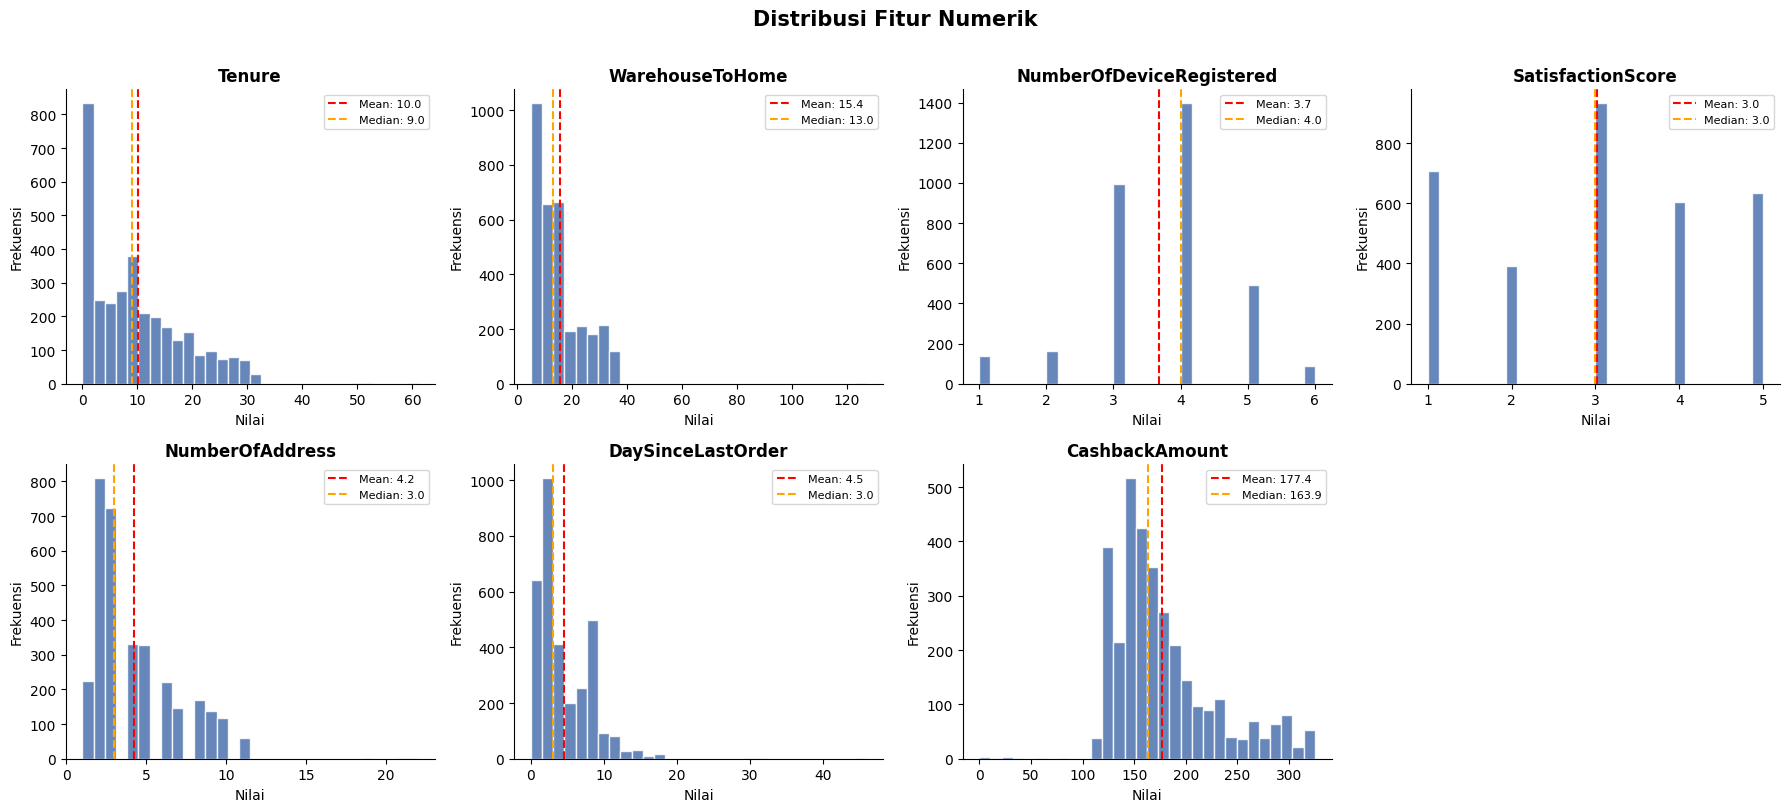

In [29]:
num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_visible(False)  # hide extra subplot
plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [30]:
skew_df = pd.DataFrame({
    'Mean':     df[num_cols].mean().round(2),
    'Median':   df[num_cols].median().round(2),
    'Std':      df[num_cols].std().round(2),
    'Min':      df[num_cols].min().round(2),
    'Max':      df[num_cols].max().round(2),
    'Skewness': df[num_cols].skew().round(3)
})
display(skew_df)

,Mean,Median,Std,Min,Max,Skewness
Tenure,10.05,9.00,8.51,0.0,61.00,0.841
WarehouseToHome,15.43,13.00,8.40,5.0,127.00,1.581
NumberOfDeviceRegistered,3.68,4.00,1.02,1.0,6.00,-0.405
SatisfactionScore,3.02,3.00,1.40,1.0,5.00,-0.086
NumberOfAddress,4.22,3.00,2.62,1.0,22.00,1.116
DaySinceLastOrder,4.50,3.00,3.60,0.0,46.00,1.496
CashbackAmount,177.42,163.88,49.31,0.0,324.99,1.088


### **4.1.3 Distribusi Fitur Kategorikal**


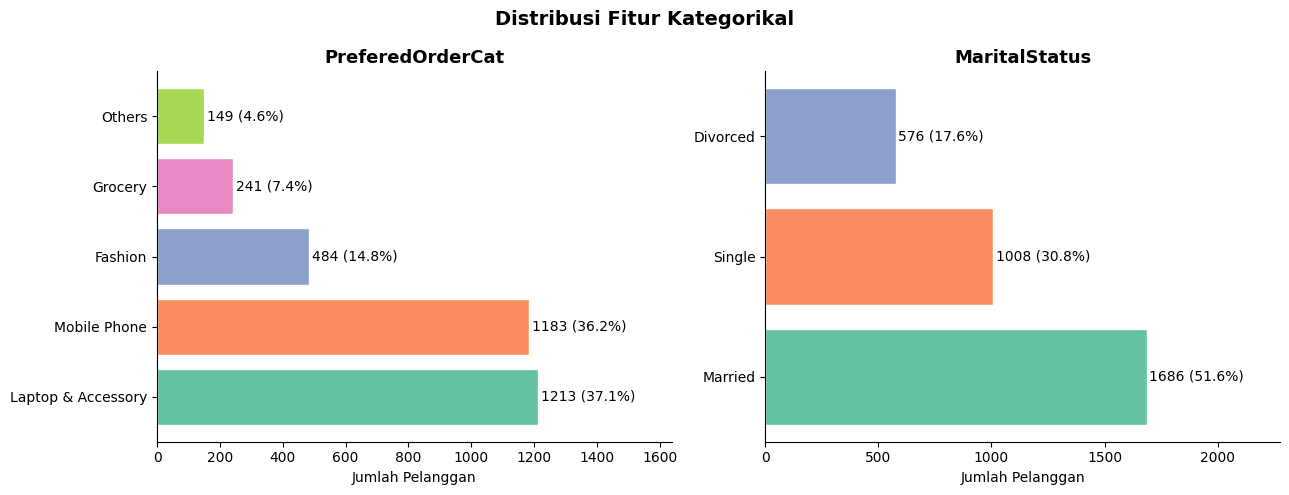

In [31]:
cat_cols = ['PreferedOrderCat', 'MaritalStatus']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True) * 100
    bars   = ax.barh(counts.index, counts.values,
                     color=sns.color_palette('Set2', len(counts)),
                     edgecolor='white')
    for bar, (v, p) in zip(bars, zip(counts.values, pcts.values)):
        ax.text(v + 10, bar.get_y() + bar.get_height()/2,
                f'{v} ({p:.1f}%)', va='center', fontsize=10)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Jumlah Pelanggan')
    ax.set_xlim(0, counts.max() * 1.35)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

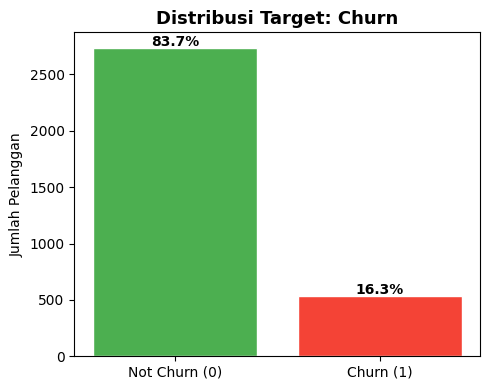

Churn    : 534 (16.3%)
Not Churn: 2,736 (83.7%)


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Not Churn (0)', 'Churn (1)'], churn_counts.values,
              color=['#4CAF50', '#F44336'], edgecolor='white')

for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct:.1f}%', ha='center', fontweight='bold')

ax.set_title('Distribusi Target: Churn', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

print(f'Churn    : {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')
print(f'Not Churn: {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')

## **4.2 Bivariate Analysis (terhadap Target)**

> 🎯 *Tujuan:* Mencari pola hubungan antara tiap fitur dengan target, untuk menjawab langsung Problem Statement di Section 1.2.

> 📌 Ini bagian paling penting untuk menjawab Problem Statement di Section 1.2 — cari pola antara tiap fitur dengan target, bukan sekadar plot tanpa insight.

### 4.2.1 Numerical Features vs Churn

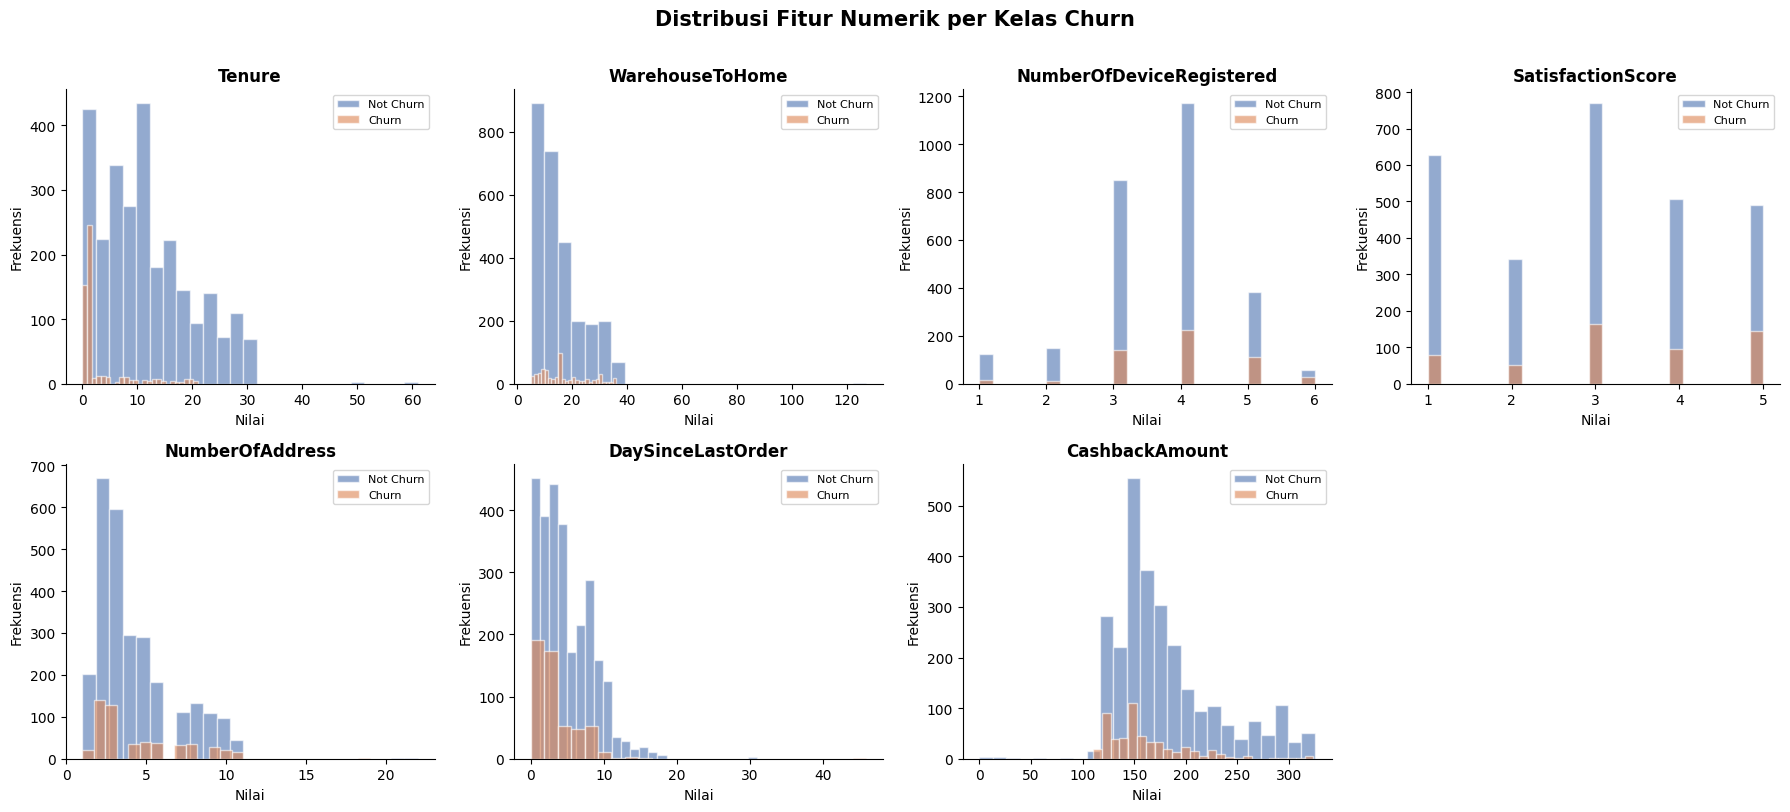

In [ ]:
#Distribution of Numeric Features per Churn Class
num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for churn_val, label, color in zip([0, 1], ['Not Churn', 'Churn'], ['#4C72B0', '#DD8452']):
        subset = df[df['Churn'] == churn_val][col]
        ax.hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik per Kelas Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

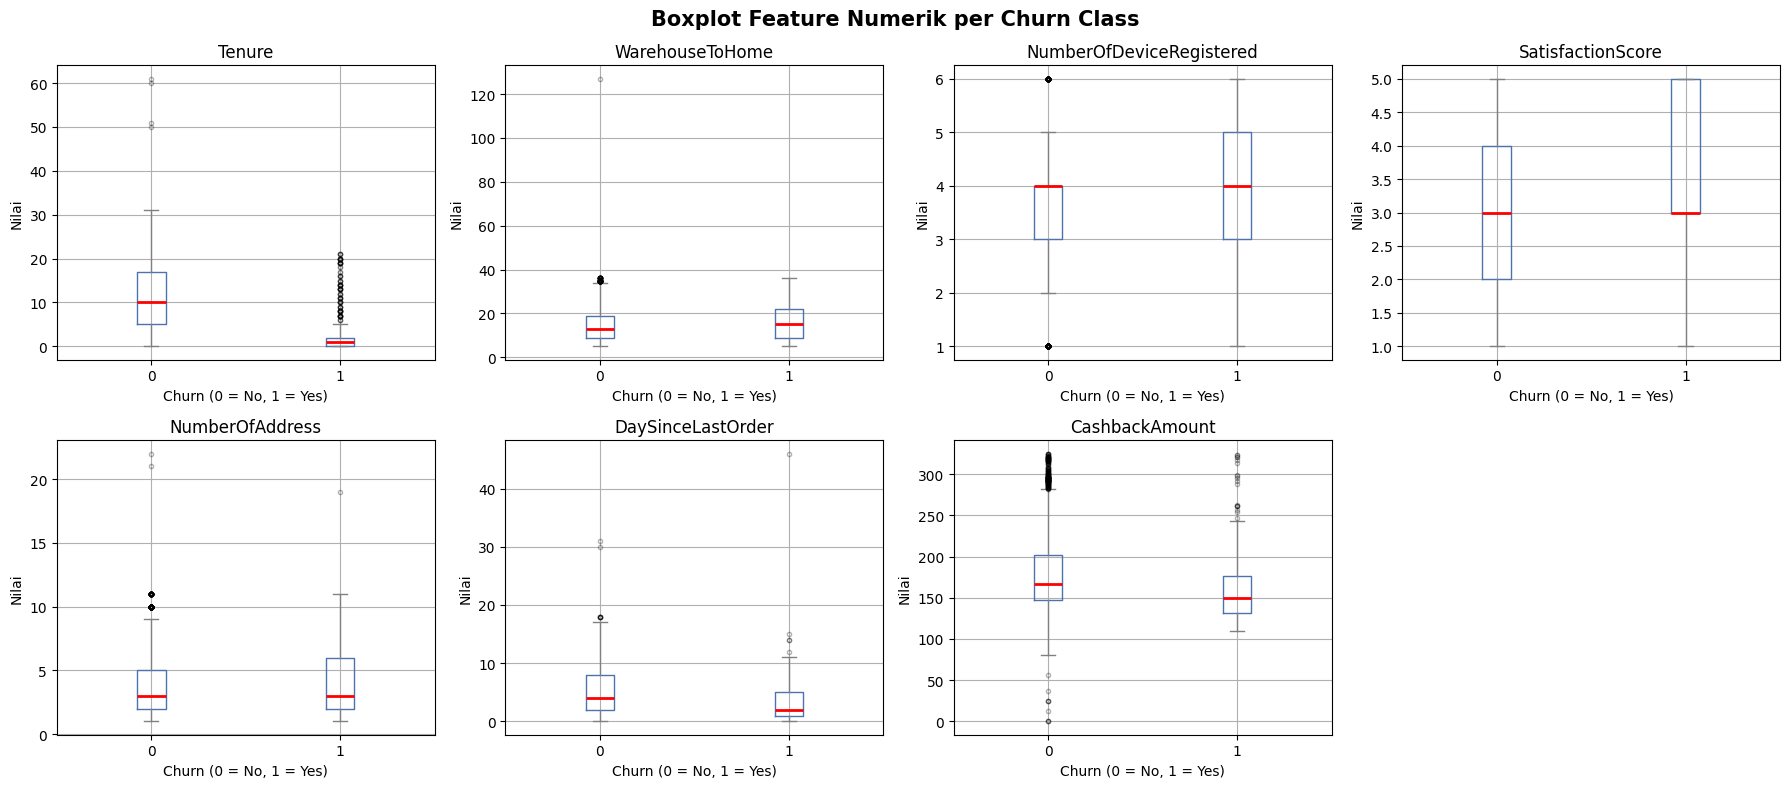

In [ ]:
#Boxplot Numeric per Churn Class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='Churn', ax=ax,
               boxprops=dict(color='#4C72B0'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn (0 = No, 1 = Yes)')
    ax.set_ylabel('Nilai')
    plt.sca(ax)
    plt.title(col)

axes[-1].set_visible(False)
plt.suptitle('Boxplot Feature Numerik per Churn Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2.2 Categorical Features vs Churn

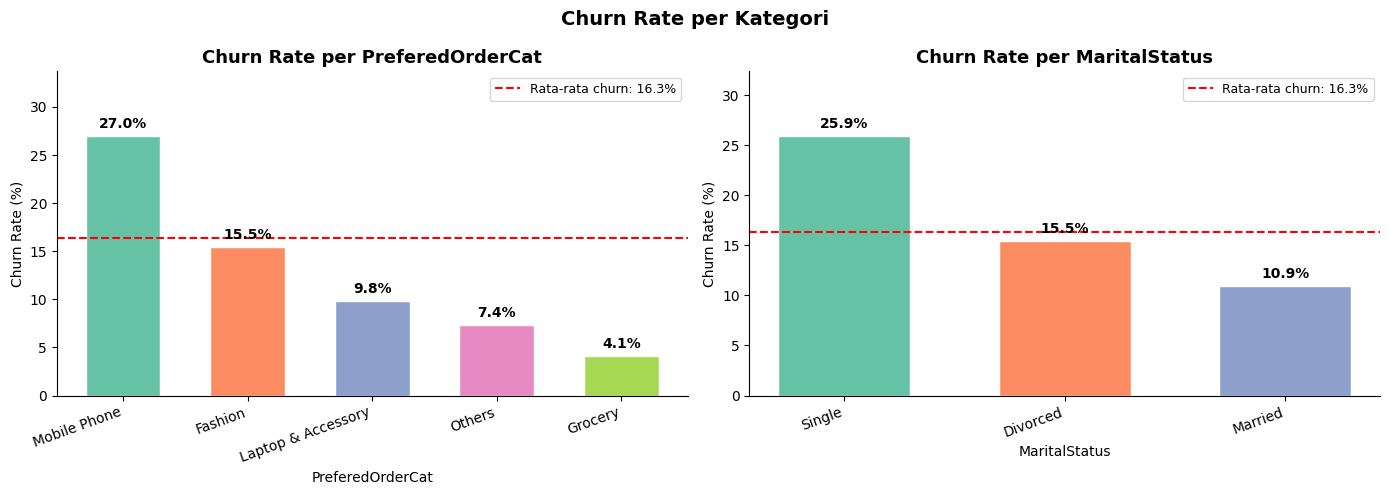

In [41]:
cat_cols = ['PreferedOrderCat', 'MaritalStatus']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette('Set2', len(churn_rate)),
                  edgecolor='white', width=0.6)
    for bar, v in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.axhline(df['Churn'].mean() * 100, color='red', linestyle='--',
               linewidth=1.5, label=f'Rata-rata churn: {df["Churn"].mean()*100:.1f}%')
    ax.set_title(f'Churn Rate per {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 1.25)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Churn Rate per Kategori', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

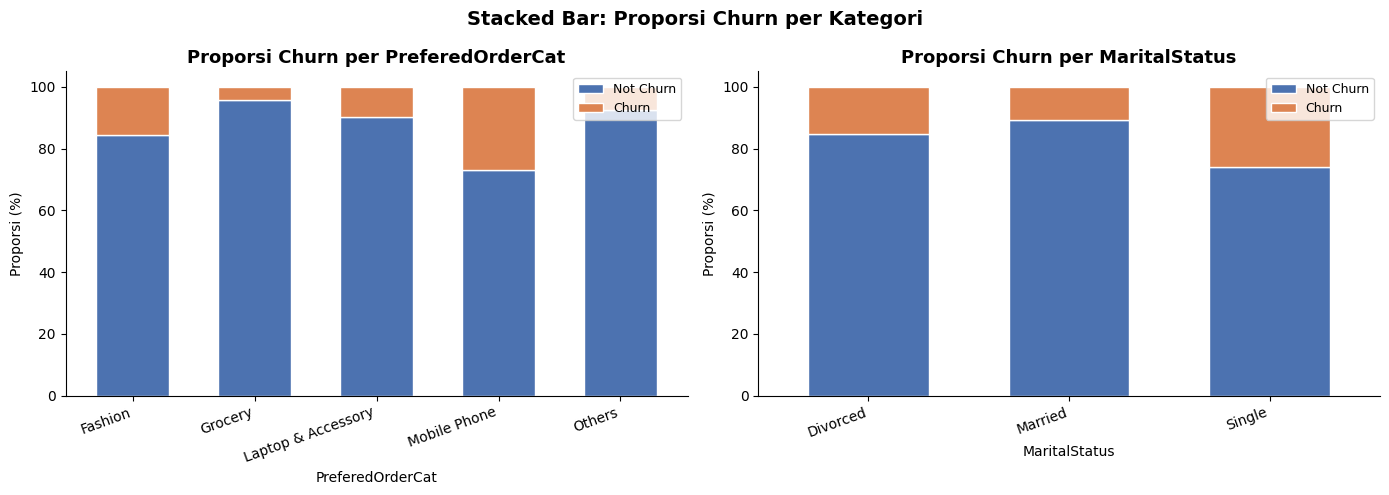

In [ ]:
#Stacked Bar Churn per Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.columns = ['Not Churn', 'Churn']
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6)
    ax.set_title(f'Proporsi Churn per {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Proporsi (%)')
    ax.legend(loc='upper right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Stacked Bar: Proporsi Churn per Kategori', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **4.3 Correlation & Multicollinearity Check**

> 🎯 *Tujuan:* Mengecek hubungan antar fitur untuk mendeteksi multikolinearitas yang bisa mengganggu interpretasi model nanti.

### 4.3.1 Correlation Heatmap

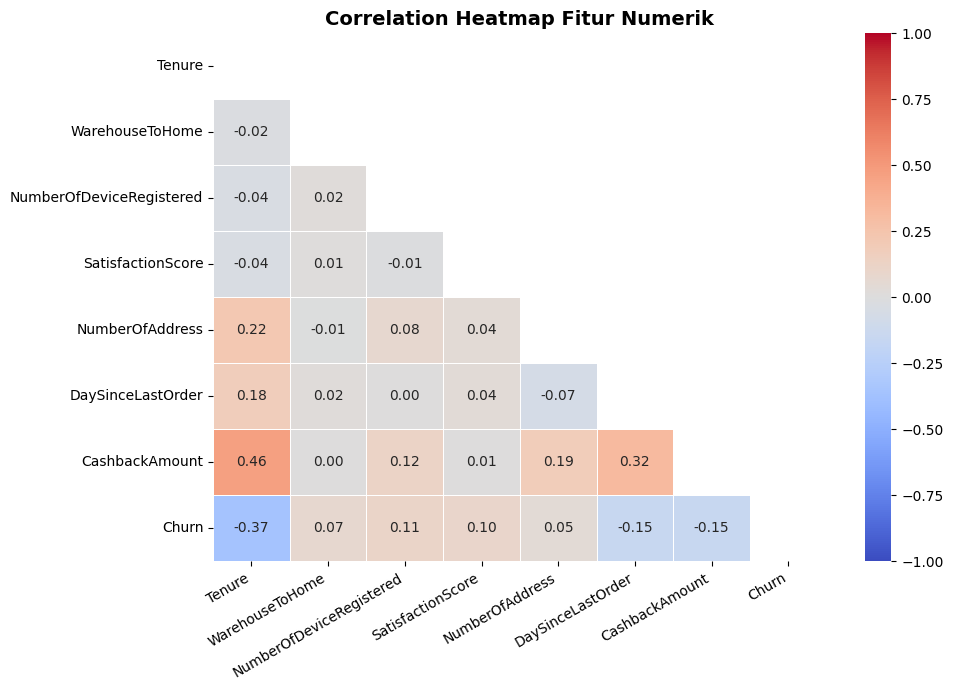

In [44]:
plt.figure(figsize=(10, 7))

corr_matrix = df[num_cols + ['Churn']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # sembunyikan segitiga atas

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})

plt.title('Correlation Heatmap Fitur Numerik', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

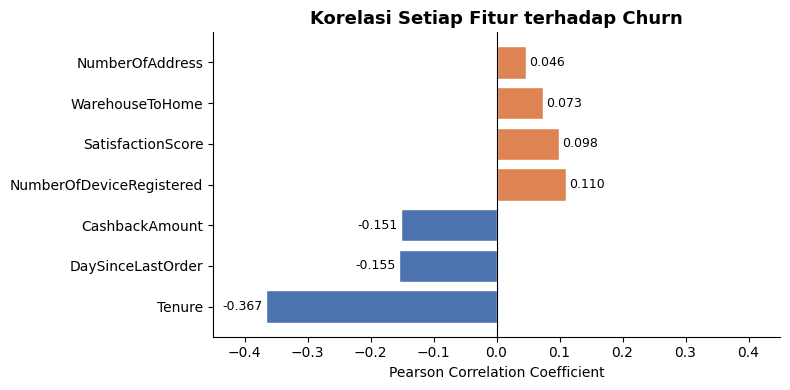

In [ ]:
#Sort Highest Correlation Towards Churn
corr_with_churn = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 4))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_with_churn.values]
bars = plt.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, corr_with_churn.values):
    plt.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.title('Korelasi Setiap Fitur terhadap Churn', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.xlim(-0.45, 0.45)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4.3.2 Pairplot Selected Feature vs Churn

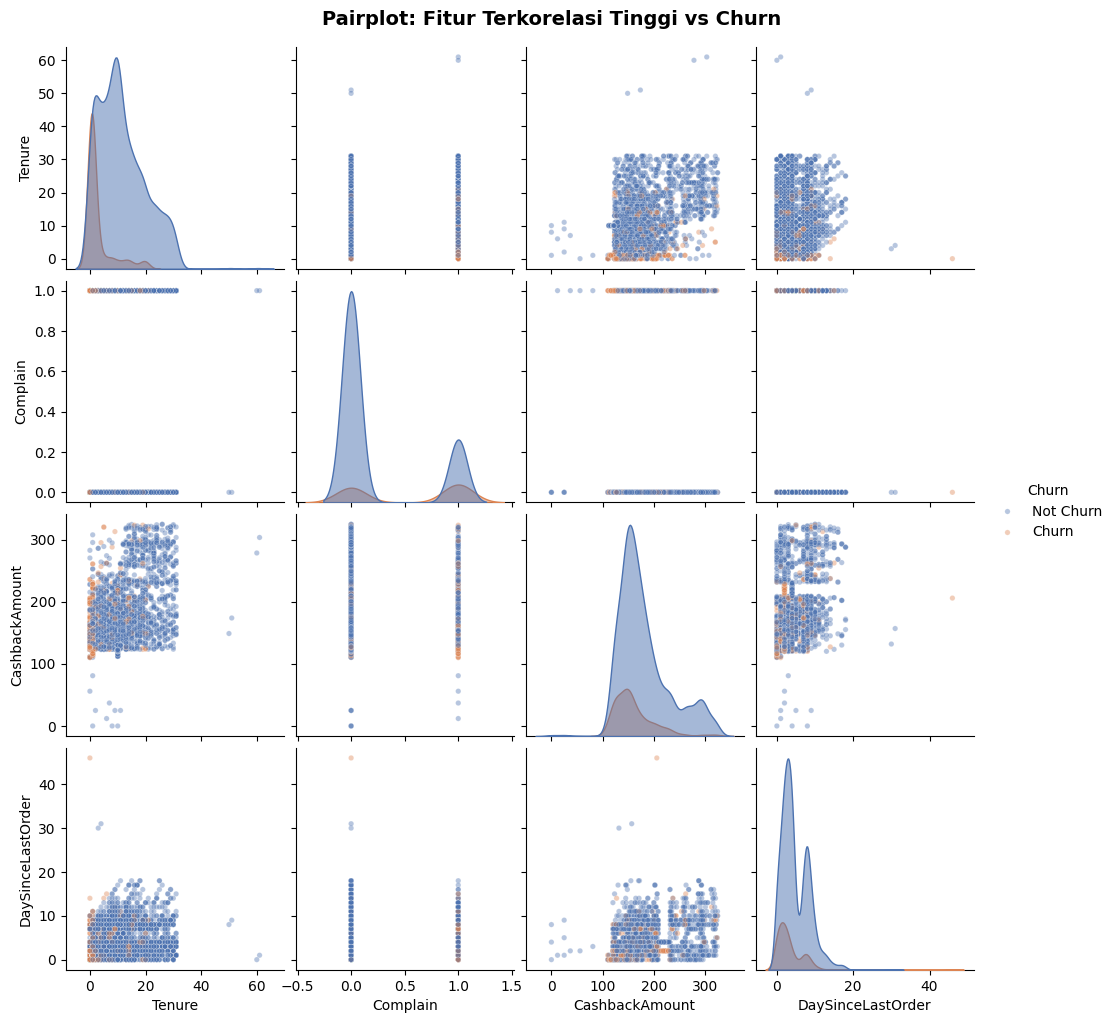

In [ ]:
top_features = ['Tenure', 'Complain', 'CashbackAmount', 'DaySinceLastOrder', 'Churn']

pair_df = df[top_features].copy()
pair_df['Churn'] = pair_df['Churn'].map({0: 'Not Churn', 1: 'Churn'})

g = sns.pairplot(pair_df, hue='Churn', palette={'Not Churn': '#4C72B0', 'Churn': '#DD8452'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'fill': True, 'alpha': 0.5})

g.figure.suptitle('Pairplot: Fitur Terkorelasi Tinggi vs Churn',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

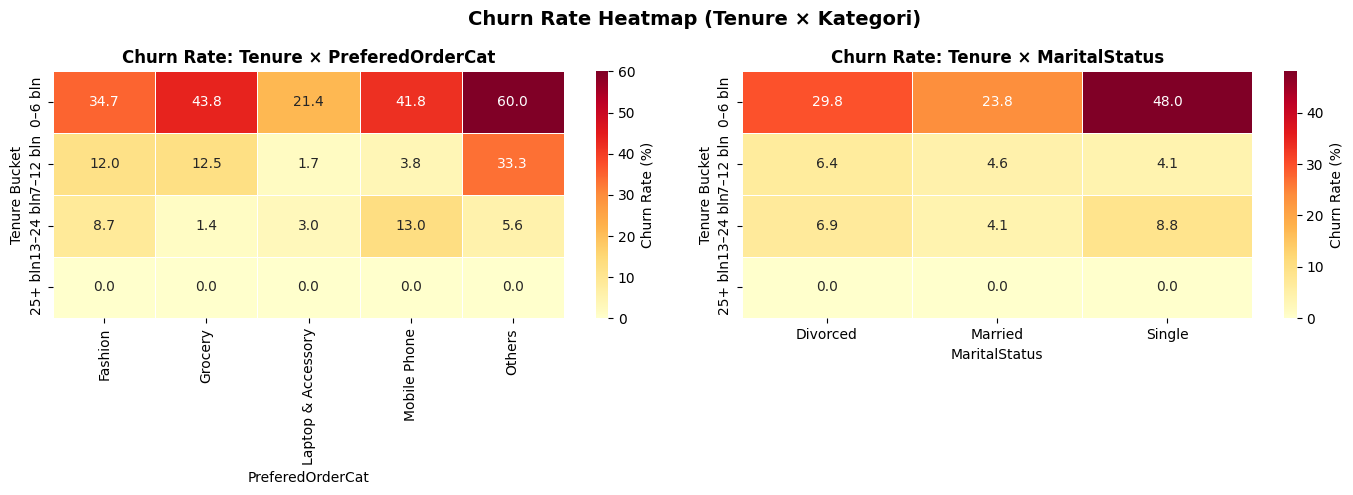

In [ ]:
#Create Tenue Bucket
df['Tenure_bucket'] = pd.cut(df['Tenure'], bins=[0, 6, 12, 24, 62],
                              labels=['0–6 bln', '7–12 bln', '13–24 bln', '25+ bln'],
                              include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['PreferedOrderCat', 'MaritalStatus']):
    pivot = df.pivot_table(values='Churn', index='Tenure_bucket',
                           columns=col, aggfunc='mean') * 100
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, linecolor='white', ax=ax,
                cbar_kws={'label': 'Churn Rate (%)'})
    ax.set_title(f'Churn Rate: Tenure × {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Tenure Bucket')

plt.suptitle('Churn Rate Heatmap (Tenure × Kategori)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Delete Helper Column Once Done
df.drop(columns=['Tenure_bucket'], inplace=True)

## **4.4 Multivariate / Interaction Analysis (opsional)**

> 🎯 *Tujuan:* Menelusuri interaksi antara beberapa fitur sekaligus untuk pola yang lebih kompleks dari yang bisa ditangkap analisis dua arah.

In [33]:
# Skip I guess ¯\_(ツ)_/¯

# **Section 5. Data Preparation**

> 🎯 *Tujuan:* Mengubah data mentah menjadi bentuk siap pakai untuk pemodelan (numerik, terskala, tanpa kategori yang belum di-encode).

## **5.1 Initialization**
- Initialization function
- Define Feature and Target

> 🎯 *Tujuan:* Menyiapkan fungsi bantu dan mendefinisikan mana kolom fitur (X) dan target (y) sebelum transformasi dimulai.

## **5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

> 🎯 *Tujuan:* Membagi data `Seen` menjadi training dan testing untuk keperluan pengembangan dan evaluasi model.

## **5.3 Handling Imbalanced Data (jika relevan)**

> 🎯 *Tujuan:* Menangani ketimpangan proporsi kelas target supaya model tidak bias ke kelas mayoritas.

> 📌 Cek proporsi kelas target di Section 5.1. Kalau timpang (misal 90:10), pertimbangkan strategi seperti class_weight, SMOTE, atau undersampling — **tapi ingat, teknik resampling hanya boleh diterapkan pada data training**, tidak pernah pada data testing/unseen, supaya evaluasi tetap realistis.

## **5.4 Data Transformation (Feature Engineering)**

> 🎯 *Tujuan:* Melakukan encoding, scaling, atau transformasi lain agar data sesuai kebutuhan algoritma yang dipakai.

## **5.5 Feature Selection**

> 🎯 *Tujuan:* Memilih fitur yang paling relevan/berkontribusi untuk mengurangi noise dan risiko overfitting.

## **5.6 Overview**

> 🎯 *Tujuan:* Merangkum hasil akhir data preparation (bentuk data final) sebelum masuk ke tahap Model Development.

# **Section 6. Model Development**

> 🎯 *Tujuan:* Membangun, membandingkan, dan menyempurnakan model machine learning menggunakan data.

## **6.1 Initialization**
- Initialization Function
- Create Custom Metrics
- Define Cross-Validation Strategy
- Create a workflow of the experiment

> 🎯 *Tujuan:* Menyiapkan fungsi metrik custom dan strategi cross-validation yang dipakai konsisten di seluruh eksperimen model.

> 📌 Tentukan strategi CV secara eksplisit (misal `StratifiedKFold` untuk klasifikasi dengan target tidak seimbang) dan simpan `RANDOM_STATE` yang sama dari Section 0. Ingat prinsip **CV-first**: bandingkan model lewat cross-validation dulu, baru evaluasi akhir di data testing — jangan sebaliknya.

## **6.2 Developing the Model Pipeline**

> 🎯 *Tujuan:* Merangkai seluruh langkah preprocessing dan model ke dalam satu objek Pipeline yang konsisten dipakai ulang.

> 📌 Gunakan `Pipeline`/`ColumnTransformer` dari scikit-learn supaya seluruh langkah preprocessing (imputasi, encoding, scaling) ikut ter-*fit* hanya pada data training di setiap fold — ini mencegah data leakage antara fold CV.

## **6.3 Model Benchmarking (Comparing model base performance)**

> 🎯 *Tujuan:* Membandingkan performa dasar beberapa algoritma (tanpa tuning) untuk memilih kandidat terbaik yang layak dituning lebih lanjut.

## **6.4 Tune Model**

> 🎯 *Tujuan:* Mengoptimalkan hyperparameter dari model kandidat terbaik hasil benchmarking untuk meningkatkan performa.

## **6.5 Analyze Model**
- Evaluate model on data testing
- Confusion Matrix / Threshold Analysis (Classification) atau Residual Analysis (Regression)
- Learning Curve Inspection

> 🎯 *Tujuan:* Mengevaluasi performa model secara mendalam di luar satu angka metrik utama, termasuk mengecek tanda overfitting/underfitting.

## **6.6 Model Calibration (Classification Only)**

> 🎯 *Tujuan:* Menyesuaikan output probabilitas model supaya lebih merepresentasikan kemungkinan sebenarnya, penting saat threshold dipakai untuk keputusan bisnis.

## **6.7 Model Explanation and Interpretation**
- Feature Importance (Tree Based Model) / Coefficient Regression (Regression Based Model)
- SHAP Value identification
- Counterfactual Analysis

> 🎯 *Tujuan:* Menjelaskan bagaimana model mengambil keputusan — penting untuk membangun kepercayaan stakeholder bisnis terhadap model.

# **Section 7. Model Deployment**

> 🎯 *Tujuan:* Menyiapkan model terlatih agar bisa dipakai di luar notebook, lengkap dengan dokumentasi teknis yang diperlukan.

## **7.1 Export Model (joblib/pickle)**

> 🎯 *Tujuan:* Menyimpan pipeline terlatih ke dalam file yang bisa dimuat ulang tanpa perlu melatih ulang dari awal.

> 📌 Minimal, export pipeline lengkap (bukan cuma model) dengan `joblib.dump()` supaya preprocessing dan model tetap satu paket saat dipakai ulang.

## **7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

> 🎯 *Tujuan:* Mendokumentasikan hal teknis yang perlu diperhatikan tim lain saat model dipakai di lingkungan produksi.

# **Section 8. Model Implementation**

> 🎯 *Tujuan:* Menjelaskan cara pakai model di dunia nyata, batasannya, dan dampak bisnisnya lewat simulasi.

## **8.1 How to implement the model?**

> 🎯 *Tujuan:* Menjelaskan langkah teknis memakai model untuk melakukan prediksi pada data baru.

## **8.2 What are the limitations of the model?**

> 🎯 *Tujuan:* Mengakui batasan model secara jujur, termasuk skenario di mana prediksinya kurang bisa diandalkan.

## **8.3 Business Calculation (Simulation using unseen data)**

> 🎯 *Tujuan:* Mensimulasikan dampak bisnis dari penggunaan model, memakai data `unseen` yang belum pernah dilihat selama proses modeling.

> 📌 Ini saatnya `unseen` data dipakai. Kaitkan hasil simulasi dengan metrik bisnis yang kamu tetapkan di Section 1.5 — misalnya, hitung estimasi kerugian akibat False Negative vs biaya operasional akibat False Positive, sesuai threshold yang dipilih.

# **Section 9. Conclusion and Recommendation**

> 🎯 *Tujuan:* Merangkum keseluruhan proyek dan menerjemahkan hasil teknis kembali ke bahasa yang dipahami stakeholder bisnis.

## **9.1 Conclusion**
- Conclusion (Model)
- Conclusion (Business)

> 🎯 *Tujuan:* Merangkum temuan utama dari sisi performa model dan sisi dampak bisnis, menjawab kembali Goals di Section 1.3.

## **9.2 Recommendation**
- Recommendation (Model)
- Recommendation (Business)

> 🎯 *Tujuan:* Memberikan rekomendasi tindak lanjut konkret berdasarkan temuan proyek, baik dari sisi teknis maupun bisnis.